In [4]:
import pandas as pd

In [5]:
df_district = pd.read_csv('../dataset/Bagerhat_historical_weather_2023_to_2025.csv')

df_district = df_district.drop('district', axis =1 )


In [6]:
df_district.columns

Index(['date', 'year', 'month', 'day', 'temp', 'humidity', 'pressure',
       'uv_index', 'aqi_us', 'aqi_eu', 'pm1', 'pm2_5', 'pm10', 'so2_ppb',
       'no2_ppb', 'o3_ppb', 'co_ppb'],
      dtype='object')

## PM_2.5

Date range: 2023-03-01 to 2025-11-20


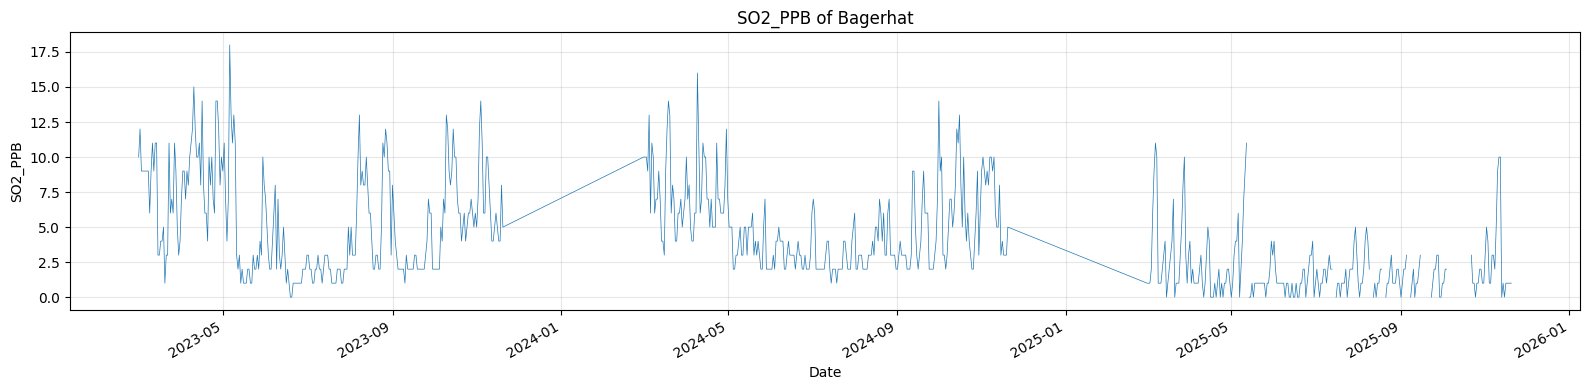

In [7]:
parameter = 'so2_ppb'
district = 'Bagerhat'

import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])


df_district = df_district[
    (df_district['date'] >= '2023-03-01') & (df_district['date'] <= '2025-11-20')
]


custom_range_df = df_district.copy()
custom_range_df['date'] = pd.to_datetime(custom_range_df['date'])

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()

print(f"Date range: {min_date.date()} to {max_date.date()}")

plt.figure(figsize=(16, 4))

# 1. Use the dataframe where you explicitly converted 'date' to datetime
plt.plot(custom_range_df['date'], custom_range_df[parameter], linewidth=0.5)

# 2. Let Matplotlib handle the date formatting automatically
plt.gcf().autofmt_xdate() 

plt.xlabel('Date')
plt.ylabel(f'{parameter.upper()}')
plt.title(f'{parameter.upper()} of {district}')
plt.grid(True, alpha=0.3) # Use alpha to make the grid less distracting
plt.tight_layout()
plt.show()



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = custom_range_df.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
# df_monthly_temp = df.set_index('date')[parameter].resample('MS').mean().reset_index()
# df_monthly_temp = df_monthly_temp.dropna()

df_monthly_temp = df.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_temp.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [9]:
df_monthly_temp.describe()

,date,year,month,day,temp,humidity,pressure,uv_index,aqi_us,aqi_eu,pm1,pm2_5,pm10,so2_ppb,no2_ppb,o3_ppb,co_ppb
count,763,763.00000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000
mean,2024-06-22 11:13:45.688073216,2023.95806,6.745740,15.466579,28.792398,81.260944,1005.866448,7.096986,88.307995,3.229358,24.625164,30.960682,44.102228,4.213630,8.053735,49.778506,205.635649
min,2023-03-01 00:00:00,2023.00000,3.000000,1.000000,22.200000,55.100000,985.200000,1.000000,27.000000,1.000000,3.000000,7.000000,7.000000,0.000000,0.000000,0.000000,4.000000
25%,2023-09-07 12:00:00,2023.00000,5.000000,8.000000,27.700000,76.600000,1002.450000,6.000000,56.000000,2.000000,10.000000,14.000000,19.000000,2.000000,4.000000,33.000000,119.000000
50%,2024-06-25 00:00:00,2024.00000,7.000000,15.000000,29.000000,81.900000,1005.300000,7.000000,76.000000,3.000000,19.000000,25.000000,37.000000,3.000000,6.000000,49.000000,169.000000
75%,2025-04-11 12:00:00,2025.00000,9.000000,23.000000,30.200000,86.700000,1009.700000,8.000000,119.000000,4.000000,35.000000,43.000000,60.000000,6.000000,11.000000,69.000000,264.000000
max,2025-11-20 00:00:00,2025.00000,11.000000,31.000000,34.400000,96.000000,1017.000000,10.000000,188.000000,6.000000,116.000000,130.000000,156.000000,18.000000,36.000000,141.000000,672.000000
std,NaN,0.80733,2.502669,8.885086,2.178539,7.628994,4.875107,1.788276,40.297851,1.333430,17.942193,20.861272,29.816324,3.385971,6.563519,25.602595,137.350179


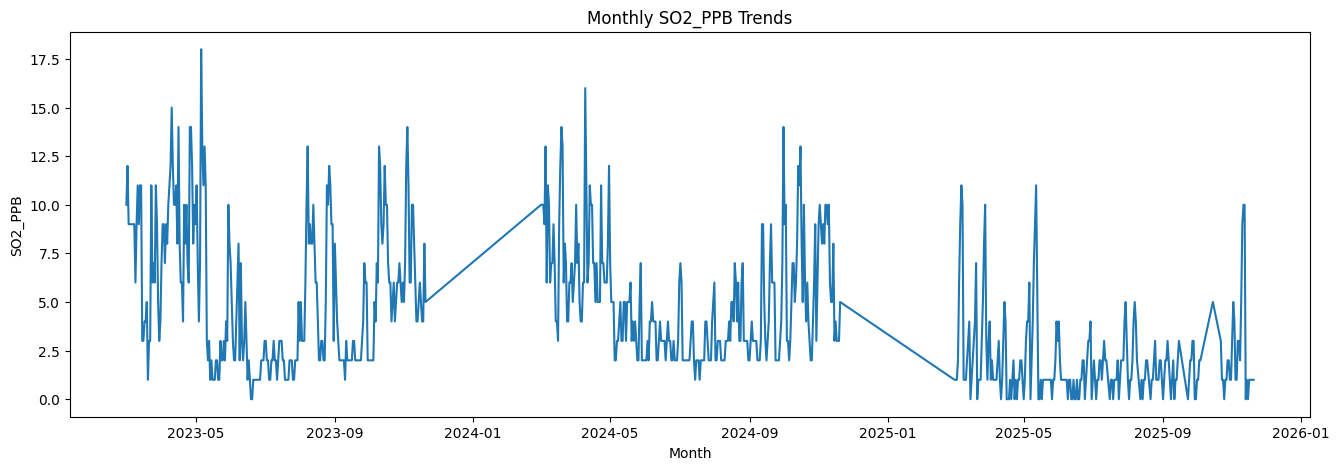

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 5))
plt.plot(df_monthly_temp['date'], df_monthly_temp[parameter])
plt.xlabel('Month')
plt.ylabel(f'{parameter.upper()}')
plt.title(f'Monthly {parameter.upper()} Trends')
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit


# 1. Define your features (Time-based for trend)
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['pm2_5'] # Use your actual column name

# 2. Chronological Split (No Shuffling)
# This keeps the last 20% of your 763 days as the 'future' test set
split_index = int(len(df_features) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Training on: {len(X_train)} days")
print(f"Testing on: {len(X_test)} days (The most recent trend)")


Training on: 610 days
Testing on: 153 days (The most recent trend)


## RF

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest + Fourier – {parameter.upper()} Prediction (Test) for {district} ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – SO2_PPB Prediction (Test) for Bagerhat ===
R²          : 0.4543
RMSE        : 14.391 °C
MSE         : 207.0922
Accuracy (± tolerance):
  ±0.5 °C :  2.61%
  ±1.0 °C :  4.58%
  ±2.0 °C :  9.80%
  ±3.0 °C : 14.38%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.2411  (±0.1418)
Scores  : [0.0431 0.142  0.2784 0.2807 0.4613]

=== Feature Importances (Top 10) ===
 feature  importance
   cos_1    0.613868
   sin_1    0.129524
year_val    0.102455
   sin_3    0.051191
   cos_3    0.040009
   sin_2    0.032235
   cos_2    0.030719


## XGB

In [13]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print(f"==== XGBoost Regression Metrics (Test) for {district} ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) for Bagerhat ====
xgboost_R^2  : 0.4678
xgboost_MSE  : 201.9800
xgboost_RMSE : 14.2120
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  5.88%
  ±1.0°C :  8.50%
  ±2.0°C : 15.69%
  ±3.0°C : 20.92%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.1823  |  Std : 0.1976

==== Top Feature Importances ====
 feature  importance
   cos_1    0.341262
   sin_2    0.229261
   sin_3    0.142307
   cos_2    0.104157
   sin_1    0.072634
   cos_3    0.067297
year_val    0.043083


## Light gbm

In [14]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print(f"==== LightGBM Regression Metrics (Test) for {district} ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) for Bagerhat ====
LGB_R^2  : 0.4811
LGB_MSE  : 196.9371
LGB_RMSE : 14.0334
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  4.58%
  ±1.0°C :  7.19%
  ±2.0°C : 13.07%
  ±3.0°C : 18.95%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.2098  |  Std : 0.1795

==== Top Feature Importances ====
 feature   importance
   cos_1 2.726756e+06
   sin_2 8.734167e+05
   sin_1 7.846515e+05
year_val 6.708574e+05
   cos_2 4.596166e+05
   sin_3 4.288642e+05
   cos_3 1.164731e+05


## CAT

In [15]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print(f"==== CatBoost Regression Metrics (Test) for {district} ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) for Bagerhat ====
CatBoost_R^2  : 0.5117
CatBoost_MSE  : 185.2904
CatBoost_RMSE : 13.6121
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  4.58%
  ±1.0°C :  7.84%
  ±2.0°C : 14.38%
  ±3.0°C : 20.92%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.1986  |  Std : 0.1844

==== Top Feature Importances ====
 feature  importance
   cos_1   37.556562
   sin_2   19.211150
   sin_3   12.414705
year_val    9.386475
   sin_1    7.996808
   cos_3    7.365799
   cos_2    6.068501


## comparision

In [16]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print(f"\n==== Model Performance Comparison for {district} ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison for Bagerhat ====
        Model      R^2    CV R2        MSE      RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.454294 0.241102 207.092214 14.390699        2.614379        4.575163        9.803922       14.379085
      XGBoost 0.467765 0.182332 201.979986 14.211966        5.882353        8.496732       15.686275       20.915033
     LightGBM 0.481053 0.209805 196.937064 14.033427        4.575163        7.189542       13.071895       18.954248
     CatBoost 0.511743 0.198574 185.290443 13.612143        4.575163        7.843137       14.379085       20.915033


In [17]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
3       CatBoost  0.511743  0.198574  0.313170         0.602422  Overfit Risk
2       LightGBM  0.481053  0.209805  0.271248         0.475621  Overfit Risk
0  Random Forest  0.454294  0.241102  0.213192         0.450000  Overfit Risk
1        XGBoost  0.467765  0.182332  0.285432         0.260022  Overfit Risk


## predicting with best model 2 years max temperature

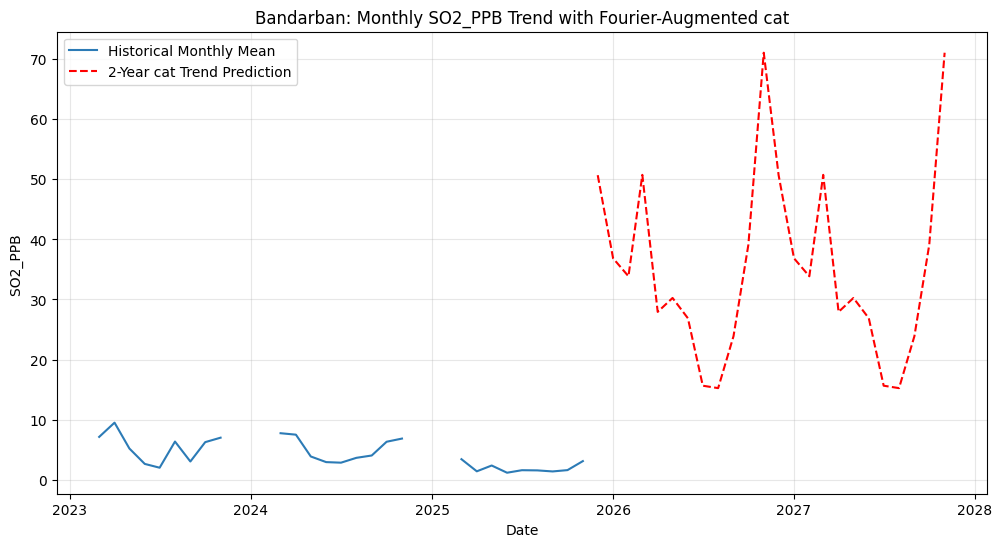

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) 
df_monthly = df.set_index('date')[parameter].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features[parameter]

# 4. Train Random Forest [cite: 145, 146]
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_max_temp = cat_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_max_temp, label='2-Year cat Trend Prediction', linestyle='--', color='red')
plt.title(f'Bandarban: Monthly {parameter.upper()} Trend with Fourier-Augmented cat')
plt.xlabel('Date')
plt.ylabel(f'{parameter.upper()} ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Khalid\AppData\Local\Temp\ipykernel_24172\3482967332.py:20: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\Khalid\AppData\Local\Temp\ipykernel_24172\3482967332.py:24: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')


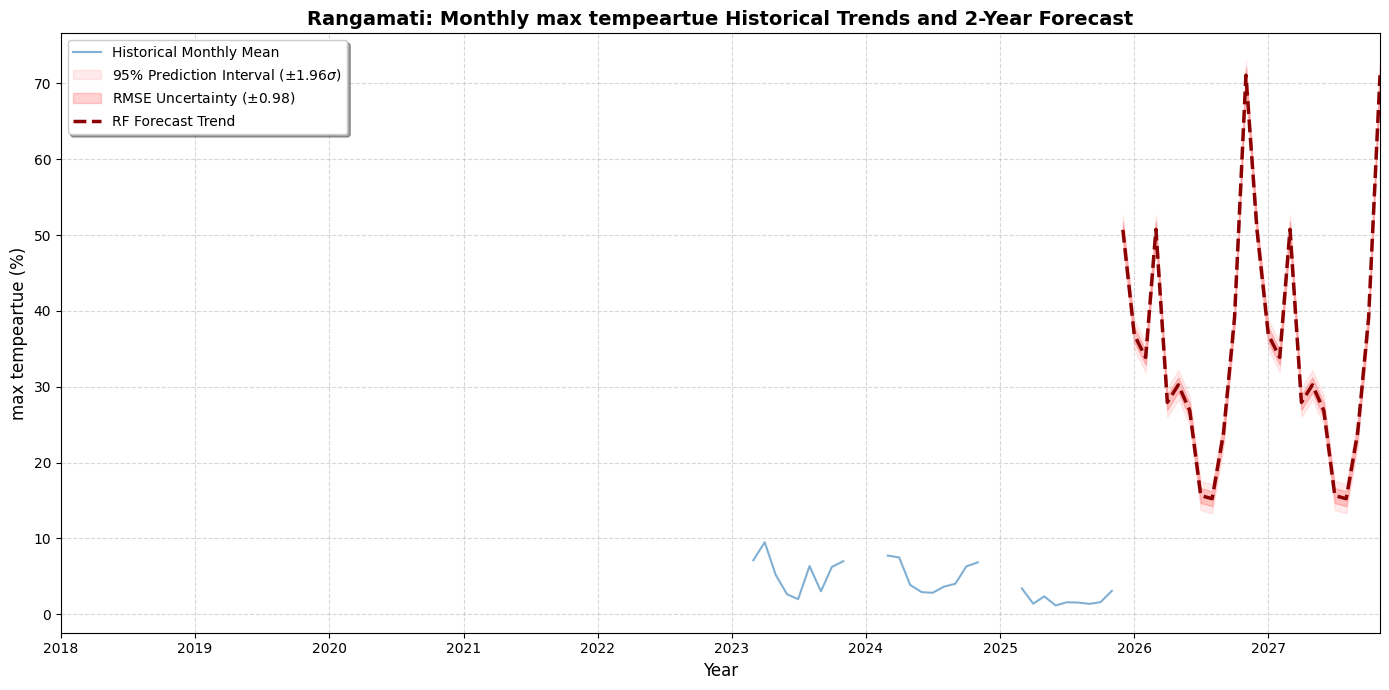

In [19]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = cat_model.predict(future_df[FEATURES])

best_model_rmse = 0.983629 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='RF Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Rangamati: Monthly max tempeartue Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('max tempeartue (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [20]:
df_predictions_max_temp = pd.DataFrame({
    'date': future_dates,
    'predicted_max_temp': predictions_max_temp
})

df_predictions_max_temp

,date,predicted_max_temp
0,2025-12-01,50.691392
1,2026-01-01,36.860200
2,2026-02-01,33.863712
3,2026-03-01,50.745336
4,2026-04-01,27.934843
5,2026-05-01,30.253636
6,2026-06-01,26.871383
7,2026-07-01,15.650329
8,2026-08-01,15.245407
9,2026-09-01,23.892806
